In [2]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches

In [3]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
'''
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/hf/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/hf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
'''

# Validation Data - sub_0011


folder = './Data/validation_data/sub_0035/ulf' 
seg_loc = folder + "/fast_seg.nii.gz"
csf_nib = nib.load(folder + "/fast_pve_0.nii.gz")
gm_nib = nib.load(folder + "/fast_pve_1.nii.gz")
wm_nib = nib.load(folder + "/fast_pve_2.nii.gz")
img_nib = nib.load(folder + "/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
noise = nib.load(folder + "/raw.nii.gz")




#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

In [4]:
csf.shape

(112, 136, 40)

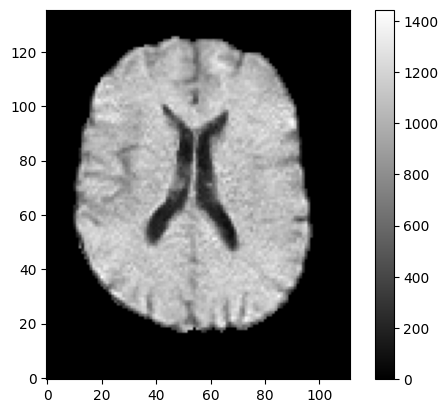

In [5]:
%matplotlib inline
slice_num = 19
plt.imshow(img_nib.get_fdata()[:,:,slice_num].T,cmap='gray')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

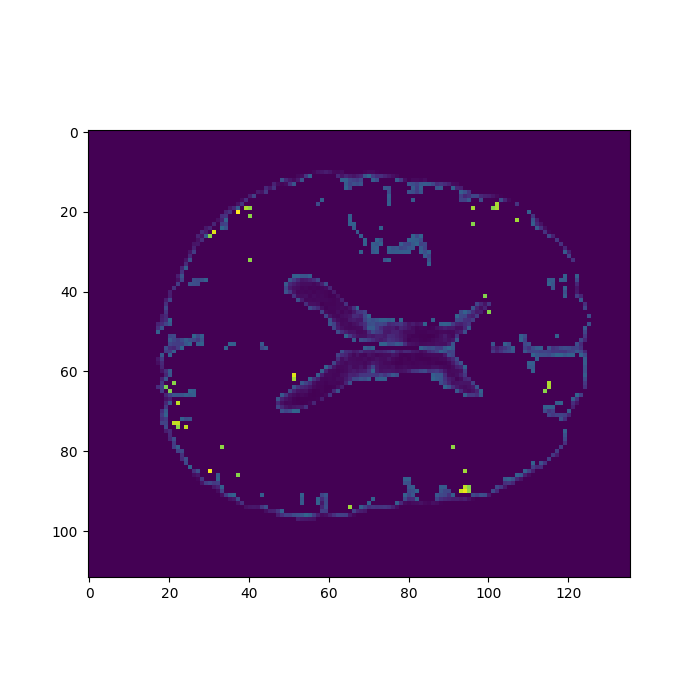

In [8]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((csf*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.99, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)



In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

In [9]:
# csf_x, csf_y, csf_w, csf_h = 54, 54, 3, 2
# gm_x, gm_y, gm_w, gm_h = 61, 87, 4, 2
# wm_x, wm_y, wm_w, wm_h = 41, 74, 4, 4


wm_x, wm_y, wm_w, wm_h = [31, 63, 6, 7]
gm_x, gm_y, gm_w, gm_h = [60, 16, 4, 4]
csf_x, csf_y, csf_w, csf_h = [55, 39, 3, 4]
# bg_x, bg_y, bg_w, bg_h = (9, 90, 5, 5)

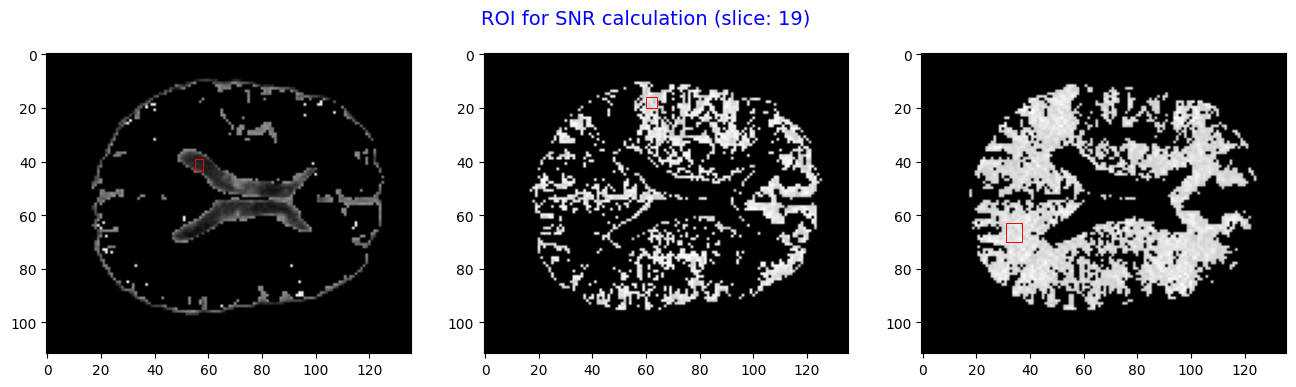

In [11]:
%matplotlib inline
# %matplotlib ipympl

fig_roi, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((csf_x, csf_y), csf_w, csf_h, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((gm_x, gm_y), gm_w, gm_h, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((wm_x, wm_y), wm_w, wm_h, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig_roi.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [ ]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

Check if there are any pixels where signal intensity = 0

In [12]:
#val data
print("WM: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num])
print("GM: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num])
print("CSF: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num])

# print(csf[104:114, 125:133, slice_num])
print("Mean signals of csf: ", csf[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num].mean(), "gm: ", gm[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num].mean(), "wm: ", wm[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num].mean())



WM:  [[1103.38818359 1130.34667969 1132.32739258 1161.56762695 1215.23950195
  1190.40991211]
 [1148.76586914 1163.04748535 1164.06726074 1138.67260742 1210.84570312
  1199.4296875 ]
 [1082.79663086 1116.72290039 1129.31848145 1078.09313965 1171.41223145
  1194.66906738]
 [1154.74938965 1159.14868164 1172.56774902 1145.45690918 1056.42810059
  1193.23950195]
 [1146.88366699 1190.31799316 1180.66442871 1144.74121094 1101.11022949
  1098.49060059]
 [1225.39294434 1190.82250977 1122.83154297 1171.88464355 1137.15539551
  1185.7890625 ]
 [1200.6138916  1173.22717285 1109.79614258 1151.73583984 1178.85766602
  1246.82092285]]
GM:  [[ 912.4342041   977.06176758  849.7666626   832.77398682]
 [1020.64074707  957.8727417   914.8314209   856.89404297]
 [ 936.39916992  919.53356934  922.98272705  806.97766113]
 [ 937.21697998  848.14593506  947.20263672  884.99090576]]
CSF:  [[175.57984924 192.38926697 167.22412109]
 [213.64509583 173.49880981 202.7646637 ]
 [187.38592529 252.33081055 208.2720947

In [13]:

#taking mean of only those samples which are 90% probabilistic


wm_roi_pixels = img_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num][wm_nib.get_fdata()[wm_y:wm_y+wm_h, wm_x:wm_x+wm_w, slice_num]>0.9]
gm_roi_pixels = img_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num][gm_nib.get_fdata()[gm_y:gm_y+gm_h, gm_x:gm_x+gm_w, slice_num]>0.9]
csf_roi_pixels = img_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num][csf_nib.get_fdata()[csf_y:csf_y+csf_h, csf_x:csf_x+csf_w, slice_num]>0.9]

print("Mean signals of csf: ",csf_roi_pixels.mean(), "gm: ", gm_roi_pixels.mean(), "wm: ", wm_roi_pixels.mean())


Mean signals of csf:  204.4732233683268 gm:  907.8578224182129 wm:  1156.4249180385045


Noise
- Loading raw image and computing BG nosie

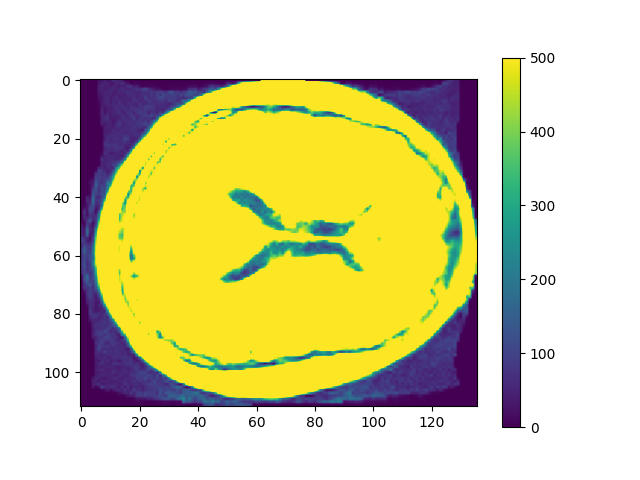

In [14]:
%matplotlib ipympl
# %matplotlib inline


plt.imshow(noise.get_fdata()[:,:,slice_num], vmax = 500)
plt.colorbar()
plt.show()


In [17]:

# bg_x, bg_y, bg_w, bg_h = (8, 88, 10, 10)
bg_x, bg_y, bg_w, bg_h = (9, 95, 8, 7)

std_bg = noise.get_fdata()[:,:,slice_num][bg_y:bg_y+bg_h,bg_x:bg_x+bg_w, ] #region-1 #Validation data
print(std_bg)
std_bg = std_bg.std()
print(std_bg)
# std_bg = noise.get_fdata()[:,:,slice_num][28:42, 20:30, ].std() #region-1 #Validation data
# print(std_bg)
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2


[[45.98947144 51.98809814 68.98420715 59.98626709 66.98466492 73.98306274
  70.98374939 72.98329163]
 [69.98397827 42.99015808 48.98878479 53.98764038 32.9924469  58.98649597
  68.98420715 61.98580933]
 [40.99061584 50.98832703 64.98512268 75.98260498 64.98512268 57.98672485
  72.98329163 77.98214722]
 [57.98672485 47.98901367 56.98695374 38.99107361 41.99038696 49.98855591
  53.98764038 55.98718262]
 [39.99084473 44.98970032 52.98786926 49.98855591 39.99084473 51.98809814
  56.98695374 43.9899292 ]
 [48.98878479 45.98947144 68.98420715 53.98764038 50.98832703 51.98809814
  62.98558044 51.98809814]
 [45.98947144 51.98809814 47.98901367 37.99130249 57.98672485 56.98695374
  48.98878479 45.98947144]]
10.736427514464555


In [18]:
rayleigh_correction = 1.53
SNR_WM =  wm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_GM = gm_roi_pixels.mean()/(std_bg*rayleigh_correction)
SNR_CSF = csf_roi_pixels.mean()/(std_bg*rayleigh_correction)

print("SNR_WM:", SNR_WM)
print("SNR_GM:", SNR_GM)
print("SNR_CSF:", SNR_CSF)

SNR_WM: 70.39895521535809
SNR_GM: 55.26709186683596
SNR_CSF: 12.447588313007502


In [19]:
''
lines_to_write = [
    "WM: " + str([wm_x, wm_y, wm_w, wm_h]),
    "GM: " + str([gm_x, gm_y, gm_w, gm_h]),
    "CSF: " + str([csf_x, csf_y, csf_w, csf_h]),
    "BG: " + str([bg_x, bg_y, bg_w, bg_h]),
    "SNR_WM: " + str(SNR_WM),
    "SNR_GM: " + str(SNR_GM),
    "SNR_CSF: " + str(SNR_CSF)
]
file_name = folder + '/snrs.txt'
with open(file_name, "w") as f:  # Open in 'w' (write) mode to overwrite or create the file
    for line in lines_to_write:
        f.write(line + "\n")  # Add a newline character to separate lines

fig_roi.savefig(folder + '/rois.png')